## Step 1 — Install Packages

In [ ]:
!pip install Pillow numpy matplotlib scikit-learn tqdm seaborn torch torchvision -q
print('✅ All packages installed!')

✅ All packages installed!


## Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3 — Setup Paths & Check GPU

In [ ]:
import os
import torch

# Paths
COVER_DIR = '/content/drive/MyDrive/dataset/cover'
STEGO_DIR = '/content/drive/MyDrive/dataset/stego'
SAVE_PATH = '/content/drive/MyDrive/dataset/srnet_best.pth'

os.makedirs(STEGO_DIR, exist_ok=True)

cover_files = [f for f in os.listdir(COVER_DIR)
               if f.lower().endswith(('.pgm', '.png', '.jpg', '.bmp'))]

print(f'✅ Cover folder : {COVER_DIR}')
print(f'✅ Stego folder : {STEGO_DIR}')
print(f'📁 Cover images : {len(cover_files)}')
assert len(cover_files) > 0, '❌ No images found! Check your Drive path.'

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nPyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name        : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️ No GPU — go to Runtime > Change runtime type > T4 GPU')

✅ Cover folder : /content/drive/MyDrive/dataset/cover
✅ Stego folder : /content/drive/MyDrive/dataset/stego
📁 Cover images : 1500

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU name        : Tesla T4
GPU memory      : 15.6 GB


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Step 4 — Create Stego Images (LSB Embedding)

In [ ]:
import numpy as np
from PIL import Image
from tqdm import tqdm
import os

# Create stego folder if it doesn't exist
os.makedirs(STEGO_DIR, exist_ok=True)

def lsb_embed(cover_array, bpp=0.4):
    arr = cover_array.copy().flatten().astype(np.uint8)
    n_bits = int(len(arr) * bpp)
    payload = np.random.randint(0, 2, n_bits, dtype=np.uint8)
    arr[:n_bits] = (arr[:n_bits] & 0xFE) | payload
    return arr.reshape(cover_array.shape)

print(f'Embedding LSB into {len(cover_files)} images...')

for fname in tqdm(cover_files, desc='Creating stego images'):
    cover_path = os.path.join(COVER_DIR, fname)
    stem = os.path.splitext(fname)[0]
    stego_path = os.path.join(STEGO_DIR, stem + '_stego.png')
    img = Image.open(cover_path).convert('L').resize((256, 256))
    arr = np.array(img)
    stego_arr = lsb_embed(arr, bpp=0.4)
    Image.fromarray(stego_arr).save(stego_path)

print(f'\nDone! Stego images saved: {len(os.listdir(STEGO_DIR))}')

Embedding LSB into 1500 images...


Creating stego images: 100%|██████████| 1500/1500 [00:47<00:00, 31.58it/s]



Done! Stego images saved: 1500


## Step 5 — Prepare Dataset (Train / Val / Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

cover_list = [
    (os.path.join(COVER_DIR, f), 0)
    for f in os.listdir(COVER_DIR)
    if f.lower().endswith(('.pgm', '.png', '.jpg', '.bmp'))
]

stego_list = [
    (os.path.join(STEGO_DIR, f), 1)
    for f in os.listdir(STEGO_DIR)
    if f.lower().endswith('.png')
]

all_data = cover_list + stego_list
paths    = [x[0] for x in all_data]
labels   = [x[1] for x in all_data]

print(f'Cover images : {len(cover_list)}')
print(f'Stego images : {len(stego_list)}')
print(f'Total        : {len(all_data)}')

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    paths, labels, test_size=0.20, random_state=42, stratify=labels)

# Split test into 50% val, 50% test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test)

print(f'\nTrain : {len(X_train)}  (80%)')
print(f'Val   : {len(X_val)}   (10%)')
print(f'Test  : {len(X_test)}   (10%)')

Cover images : 1500
Stego images : 1500
Total        : 3000

Train : 2400  (80%)
Val   : 300   (10%)
Test  : 300   (10%)


## Step 6 — Dataset Class with SRM Filter

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# SRM high-pass filter — helps detect LSB noise
_SRM_KERNEL = torch.tensor(
    [[-1,  2, -1],
     [ 2, -4,  2],
     [-1,  2, -1]],
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0) / 4.0

class StegDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert('L').resize((256, 256))
        arr    = np.array(img, dtype=np.float32) / 255.0
        tensor = torch.tensor(arr).unsqueeze(0)

        # Apply SRM filter
        tensor = F.conv2d(
            tensor.unsqueeze(0), _SRM_KERNEL, padding=1
        ).squeeze(0)

        if self.augment:
            if torch.rand(1).item() > 0.5:
                tensor = torch.flip(tensor, dims=[2])
            if torch.rand(1).item() > 0.5:
                tensor = torch.flip(tensor, dims=[1])

        return tensor, self.labels[idx]

train_ds = StegDataset(X_train, y_train, augment=True)
val_ds   = StegDataset(X_val,   y_val,   augment=False)
test_ds  = StegDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train dataset : {len(train_ds)} images')
print(f'Val dataset   : {len(val_ds)} images')
print(f'Test dataset  : {len(test_ds)} images')

sample_img, sample_label = train_ds[0]
print(f'\nSample shape : {sample_img.shape}')
print(f'Sample label : {sample_label}  (0=cover, 1=stego)')
print(f'Value range  : [{sample_img.min():.3f}, {sample_img.max():.3f}]')

Train dataset : 2400 images
Val dataset   : 300 images
Test dataset  : 300 images

Sample shape : torch.Size([1, 256, 256])
Sample label : 1  (0=cover, 1=stego)
Value range  : [-0.295, 0.278]


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Step 7 — Define SRNet Model

In [ ]:
import torch.nn as nn

class SRNetLayer1(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.tanh(self.bn(self.conv(x)))

class SRNetLayer2(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class SRNetLayer3(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.pool = nn.AvgPool2d(3, stride=2, padding=1)
    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return self.pool(out + self.skip(x))

class SRNetLayer4(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(F.relu(self.bn(self.conv(x))))

class SRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t1_1 = SRNetLayer1(1,  64)
        self.t1_2 = SRNetLayer1(64, 16)
        self.t2_1 = SRNetLayer2(16, 16)
        self.t2_2 = SRNetLayer2(16, 16)
        self.t2_3 = SRNetLayer2(16, 16)
        self.t2_4 = SRNetLayer2(16, 16)
        self.t2_5 = SRNetLayer2(16, 16)
        self.t3_1 = SRNetLayer3(16,  16)
        self.t3_2 = SRNetLayer3(16,  64)
        self.t3_3 = SRNetLayer3(64, 128)
        self.t3_4 = SRNetLayer3(128, 256)
        self.t4   = SRNetLayer4(256, 512)
        self.fc   = nn.Linear(512, 2)

    def forward(self, x):
        x = self.t1_2(self.t1_1(x))
        x = self.t2_1(x) + x
        x = self.t2_2(x) + x
        x = self.t2_3(x) + x
        x = self.t2_4(x) + x
        x = self.t2_5(x) + x
        x = self.t3_1(x)
        x = self.t3_2(x)
        x = self.t3_3(x)
        x = self.t3_4(x)
        x = self.t4(x).view(-1, 512)
        return self.fc(x)

model = SRNet().to(device)
print(f'✅ Model ready!')
print(f'Device     : {device}')
print(f'Parameters : {sum(p.numel() for p in model.parameters()):,}')

with torch.no_grad():
    dummy = torch.zeros(2, 1, 256, 256).to(device)
    print(f'Output shape: {model(dummy).shape}')

✅ Model ready!
Device     : cuda
Parameters : 1,626,402
Output shape: torch.Size([2, 2])


## Step 8 — Training Setup (Optimizer, Scheduler, Loss)

In [ ]:
import torch.optim as optim

EPOCHS        = 30
WARMUP_EPOCHS = 3
BASE_LR       = 1e-3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-5)

def get_warmup_lr(epoch):
    return BASE_LR * epoch / WARMUP_EPOCHS

print(f'✅ Optimizer  : AdamW  (lr={BASE_LR})')
print(f'✅ Scheduler  : CosineAnnealingLR (after {WARMUP_EPOCHS} warmup epochs)')
print(f'✅ Loss       : CrossEntropyLoss (label_smoothing=0.1)')
print(f'✅ Epochs     : {EPOCHS}  |  Warmup : {WARMUP_EPOCHS}')
print(f'✅ Save path  : {SAVE_PATH}')

✅ Optimizer  : AdamW  (lr=0.001)
✅ Scheduler  : CosineAnnealingLR (after 3 warmup epochs)
✅ Loss       : CrossEntropyLoss (label_smoothing=0.1)
✅ Epochs     : 30  |  Warmup : 3
✅ Save path  : /content/drive/MyDrive/dataset/srnet_best.pth


## Step 9 — Train the Model

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):

    # Warmup LR
    if epoch <= WARMUP_EPOCHS:
        for pg in optimizer.param_groups:
            pg['lr'] = get_warmup_lr(epoch)

    # --- Train ---
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * imgs.size(0)
        t_correct += (out.argmax(1) == lbls).sum().item()
        t_total   += imgs.size(0)

    # --- Validate ---
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total   += imgs.size(0)

    t_acc = t_correct / t_total
    v_acc = v_correct / v_total
    train_losses.append(t_loss / t_total)
    val_losses.append(v_loss / v_total)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    print(f'Epoch {epoch:02d} | Train Loss: {t_loss/t_total:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss/v_total:.4f} Acc: {v_acc:.4f}')

    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  💾 Best model saved! Val Acc: {best_val_acc:.4f}')

    if epoch > WARMUP_EPOCHS:
        scheduler.step()

print(f'\n✅ Training complete! Best Val Acc: {best_val_acc:.4f}')

Epoch 01 | Train Loss: 0.4296 Acc: 0.8683 | Val Loss: 1.1413 Acc: 0.5067
  💾 Best model saved! Val Acc: 0.5067


Epoch 02 | Train Loss: 0.3770 Acc: 0.8967 | Val Loss: 0.9635 Acc: 0.6933
  💾 Best model saved! Val Acc: 0.6933


Epoch 03 | Train Loss: 0.3592 Acc: 0.9087 | Val Loss: 0.5152 Acc: 0.7467
  💾 Best model saved! Val Acc: 0.7467


Epoch 04 | Train Loss: 0.3377 Acc: 0.9263 | Val Loss: 0.7875 Acc: 0.8033
  💾 Best model saved! Val Acc: 0.8033


Epoch 05 | Train Loss: 0.3290 Acc: 0.9308 | Val Loss: 0.3476 Acc: 0.9067
  💾 Best model saved! Val Acc: 0.9067


...

Epoch 26 | Train Loss: 0.2600 Acc: 0.9654 | Val Loss: 0.2729 Acc: 0.9633
  💾 Best model saved! Val Acc: 0.9633


Epoch 27 | Train Loss: 0.2535 Acc: 0.9771 | Val Loss: 0.2791 Acc: 0.9467


Epoch 28 | Train Loss: 0.2560 Acc: 0.9704 | Val Loss: 0.2626 Acc: 0.9733
  💾 Best model saved! Val Acc: 0.9733


Epoch 29 | Train Loss: 0.2543 Acc: 0.9725 | Val Loss: 0.2633 Acc: 0.9633


Epoch 30 | Train Loss: 0.2503 Acc: 0.9762 | Val Loss: 0.2638 Acc: 0.9667

✅ Training complete! Best Val Acc: 0.9733


## Step 10 — Plot Training Curves

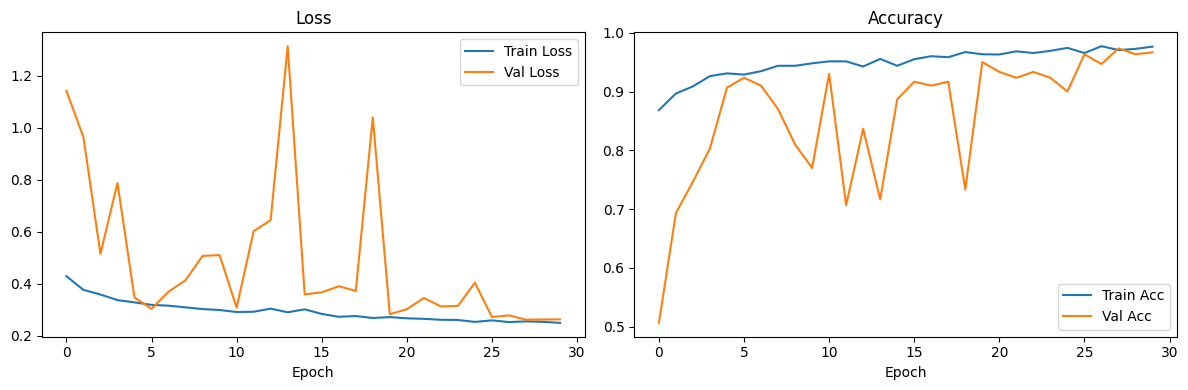

✅ Training curves saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/training_curves.png')
plt.show()
print('✅ Training curves saved!')

## Step 11 — Evaluate on Test Set + Confusion Matrix

              precision    recall  f1-score   support

       Cover       0.96      0.95      0.96       150
       Stego       0.95      0.96      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



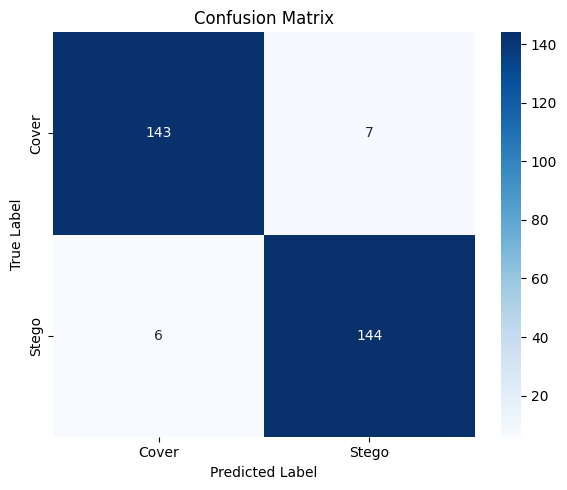

✅ Confusion matrix saved!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out  = model(imgs)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=['Cover', 'Stego']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cover', 'Stego'],
            yticklabels=['Cover', 'Stego'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix.png')
plt.show()
print('✅ Confusion matrix saved!')

## Step 12 — Predict on a Single Image (Upload from PC)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = '/content/drive/MyDrive/dataset/srnet_best.pth'

class SRNetLayer1(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.tanh(self.bn(self.conv(x)))

class SRNetLayer2(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class SRNetLayer3(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.pool = nn.AvgPool2d(3, stride=2, padding=1)
    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return self.pool(out + self.skip(x))

class SRNetLayer4(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(F.relu(self.bn(self.conv(x))))

class SRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t1_1 = SRNetLayer1(1,  64)
        self.t1_2 = SRNetLayer1(64, 16)
        self.t2_1 = SRNetLayer2(16, 16)
        self.t2_2 = SRNetLayer2(16, 16)
        self.t2_3 = SRNetLayer2(16, 16)
        self.t2_4 = SRNetLayer2(16, 16)
        self.t2_5 = SRNetLayer2(16, 16)
        self.t3_1 = SRNetLayer3(16,  16)
        self.t3_2 = SRNetLayer3(16,  64)
        self.t3_3 = SRNetLayer3(64, 128)
        self.t3_4 = SRNetLayer3(128, 256)
        self.t4   = SRNetLayer4(256, 512)
        self.fc   = nn.Linear(512, 2)

    def forward(self, x):
        x = self.t1_2(self.t1_1(x))
        x = self.t2_1(x) + x
        x = self.t2_2(x) + x
        x = self.t2_3(x) + x
        x = self.t2_4(x) + x
        x = self.t2_5(x) + x
        x = self.t3_1(x)
        x = self.t3_2(x)
        x = self.t3_3(x)
        x = self.t3_4(x)
        x = self.t4(x).view(-1, 512)
        return self.fc(x)

model = SRNet().to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print('✅ Model loaded from Drive — ready to predict!')

_SRM_KERNEL = torch.tensor(
    [[-1,  2, -1],
     [ 2, -4,  2],
     [-1,  2, -1]],
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0) / 4.0

def preprocess(image_path):
    img = Image.open(image_path).convert('L').resize((256, 256))
    arr = np.array(img, dtype=np.float32) / 255.0
    tensor = torch.tensor(arr).unsqueeze(0)
    tensor = F.conv2d(tensor.unsqueeze(0), _SRM_KERNEL, padding=1).squeeze(0)
    return tensor.unsqueeze(0).to(device)

def predict(image_path):
    model.eval()
    img = preprocess(image_path)
    with torch.no_grad():
        output = model(img)
        probs  = torch.softmax(output, dim=1)
        pred   = torch.argmax(probs, dim=1).item()

    cover_pct = round(probs[0][0].item() * 100, 2)
    stego_pct = round(probs[0][1].item() * 100, 2)

    label = 'STEGO 🔴' if pred == 1 else 'COVER 🟢'
    print('-' * 35)
    print(f'File      : {image_path.split("/")[-1]}')
    print(f'Prediction: {label}')
    print(f'Cover Prob: {cover_pct}%')
    print(f'Stego Prob: {stego_pct}%')
    print('-' * 35)

uploaded = files.upload()
filename = list(uploaded.keys())[0]
filepath = f'/content/{filename}'
print(f'\nUploaded: {filename}')
predict(filepath)# for cover img predictio

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from Drive — ready to predict!


Saving 1.pgm to 1 (2).pgm

Uploaded: 1 (2).pgm
-----------------------------------
File      : 1 (2).pgm
Prediction: COVER 🟢
Cover Prob: 95.02%
Stego Prob: 4.98%
-----------------------------------


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = '/content/drive/MyDrive/dataset/srnet_best.pth'

class SRNetLayer1(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.tanh(self.bn(self.conv(x)))

class SRNetLayer2(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class SRNetLayer3(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.pool = nn.AvgPool2d(3, stride=2, padding=1)
    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return self.pool(out + self.skip(x))

class SRNetLayer4(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(F.relu(self.bn(self.conv(x))))

class SRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t1_1 = SRNetLayer1(1,  64)
        self.t1_2 = SRNetLayer1(64, 16)
        self.t2_1 = SRNetLayer2(16, 16)
        self.t2_2 = SRNetLayer2(16, 16)
        self.t2_3 = SRNetLayer2(16, 16)
        self.t2_4 = SRNetLayer2(16, 16)
        self.t2_5 = SRNetLayer2(16, 16)
        self.t3_1 = SRNetLayer3(16,  16)
        self.t3_2 = SRNetLayer3(16,  64)
        self.t3_3 = SRNetLayer3(64, 128)
        self.t3_4 = SRNetLayer3(128, 256)
        self.t4   = SRNetLayer4(256, 512)
        self.fc   = nn.Linear(512, 2)

    def forward(self, x):
        x = self.t1_2(self.t1_1(x))
        x = self.t2_1(x) + x
        x = self.t2_2(x) + x
        x = self.t2_3(x) + x
        x = self.t2_4(x) + x
        x = self.t2_5(x) + x
        x = self.t3_1(x)
        x = self.t3_2(x)
        x = self.t3_3(x)
        x = self.t3_4(x)
        x = self.t4(x).view(-1, 512)
        return self.fc(x)

model = SRNet().to(device)
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print('✅ Model loaded from Drive — ready to predict!')

_SRM_KERNEL = torch.tensor(
    [[-1,  2, -1],
     [ 2, -4,  2],
     [-1,  2, -1]],
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0) / 4.0

def preprocess(image_path):
    img = Image.open(image_path).convert('L').resize((256, 256))
    arr = np.array(img, dtype=np.float32) / 255.0
    tensor = torch.tensor(arr).unsqueeze(0)
    tensor = F.conv2d(tensor.unsqueeze(0), _SRM_KERNEL, padding=1).squeeze(0)
    return tensor.unsqueeze(0).to(device)

def predict(image_path):
    model.eval()
    img = preprocess(image_path)
    with torch.no_grad():
        output = model(img)
        probs  = torch.softmax(output, dim=1)
        pred   = torch.argmax(probs, dim=1).item()

    cover_pct = round(probs[0][0].item() * 100, 2)
    stego_pct = round(probs[0][1].item() * 100, 2)

    label = 'STEGO 🔴' if pred == 1 else 'COVER 🟢'
    print('-' * 35)
    print(f'File      : {image_path.split("/")[-1]}')
    print(f'Prediction: {label}')
    print(f'Cover Prob: {cover_pct}%')
    print(f'Stego Prob: {stego_pct}%')
    print('-' * 35)

uploaded = files.upload()
filename = list(uploaded.keys())[0]
filepath = f'/content/{filename}'
print(f'\nUploaded: {filename}')
predict(filepath)# for cover img predictio

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from Drive — ready to predict!


Saving 1_stego.png to 1_stego (1).png

Uploaded: 1_stego (1).png
-----------------------------------
File      : 1_stego (1).png
Prediction: STEGO 🔴
Cover Prob: 0.87%
Stego Prob: 99.13%
-----------------------------------
